In [11]:
import cv2
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

def play_carla_marathon(base_dir, folder_list, fps=30):
    delay = 1.0 / fps

    try:
        for folder_name in folder_list:
            folder_path = os.path.join(base_dir, folder_name)
            rgb_dir = os.path.join(folder_path, 'rgb')
            seg_dir = os.path.join(folder_path, 'segmentation_colored')

            if not os.path.exists(rgb_dir):
                print(f"Missing folder: {rgb_dir}")
                continue

            rgb_images = sorted([
                f for f in os.listdir(rgb_dir)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])

            if len(rgb_images) == 0:
                print(f"No images in {rgb_dir}")
                continue

            for img_name in rgb_images:
                start_time = time.time()

                rgb_path = os.path.join(rgb_dir, img_name)
                seg_path = os.path.join(seg_dir, img_name)

                if not os.path.exists(seg_path):
                    continue

                rgb_img = cv2.imread(rgb_path)
                seg_img = cv2.imread(seg_path)

                if rgb_img is None or seg_img is None:
                    continue

                stitched_frame = np.hstack((rgb_img, seg_img))

                # Convert BGR -> RGB for matplotlib
                stitched_frame = cv2.cvtColor(stitched_frame, cv2.COLOR_BGR2RGB)

                clear_output(wait=True)
                plt.figure(figsize=(12, 4))
                plt.imshow(stitched_frame)
                plt.axis('off')
                plt.title(f"{folder_name} | {img_name}")
                plt.show()

                elapsed = time.time() - start_time
                time.sleep(max(0, delay - elapsed))

    except KeyboardInterrupt:
        print("Playback stopped by user.")

In [12]:
# --- Run Configuration ---
carla_base_dir = r"./"

folders_to_play = [f"{i:02d}" for i in range(21)]

play_carla_marathon(carla_base_dir, folders_to_play, fps=30)

Playback stopped by user.


In [13]:
import cv2
import os
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

def analyze_segmentation_dataset(base_dir, folder_list, sample_limit=None):
    all_colors = Counter()
    total_images = 0

    for folder_name in folder_list:
        seg_dir = os.path.join(base_dir, folder_name, "segmentation_colored")

        if not os.path.exists(seg_dir):
            print(f"Missing: {seg_dir}")
            continue

        files = sorted([
            f for f in os.listdir(seg_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

        if sample_limit:
            files = files[:sample_limit]

        for f in files:
            path = os.path.join(seg_dir, f)
            img = cv2.imread(path)

            if img is None:
                continue

            total_images += 1

            # reshape do listy pikseli (RGB/BGR)
            pixels = img.reshape(-1, 3)

            # liczymy unikalne kolory (klasy w maskach kolorowych)
            for px in pixels[::50]:  # subsampling żeby było szybciej
                all_colors[tuple(px)] += 1

    print("\n===== DATASET ANALYSIS =====")
    print("Total images processed:", total_images)
    print("Approx unique colors (classes):", len(all_colors))

    # TOP KLASY
    print("\nTop 20 most frequent colors (BGR):")
    for color, count in all_colors.most_common(20):
        print(color, "->", count)

    # wizualizacja
    top_colors = all_colors.most_common(10)
    colors = [c[0] for c in top_colors]
    counts = [c[1] for c in top_colors]

    plt.figure(figsize=(10,4))
    plt.bar(range(len(counts)), counts)
    plt.title("Top segmentation colors (proxy classes)")
    plt.show()

    return all_colors

Missing: ./10/segmentation_colored

===== DATASET ANALYSIS =====
Total images processed: 4000
Approx unique colors (classes): 24

Top 20 most frequent colors (BGR):
(np.uint8(128), np.uint8(64), np.uint8(128)) -> 9621874
(np.uint8(70), np.uint8(70), np.uint8(70)) -> 6947092
(np.uint8(180), np.uint8(130), np.uint8(70)) -> 3156715
(np.uint8(35), np.uint8(142), np.uint8(107)) -> 1487792
(np.uint8(232), np.uint8(35), np.uint8(244)) -> 699874
(np.uint8(50), np.uint8(234), np.uint8(157)) -> 671077
(np.uint8(142), np.uint8(0), np.uint8(0)) -> 438137
(np.uint8(80), np.uint8(90), np.uint8(55)) -> 388144
(np.uint8(70), np.uint8(0), np.uint8(0)) -> 271478
(np.uint8(153), np.uint8(153), np.uint8(153)) -> 236723
(np.uint8(160), np.uint8(190), np.uint8(110)) -> 191110
(np.uint8(140), np.uint8(150), np.uint8(230)) -> 118278
(np.uint8(50), np.uint8(120), np.uint8(170)) -> 87698
(np.uint8(81), np.uint8(0), np.uint8(81)) -> 75962
(np.uint8(0), np.uint8(220), np.uint8(220)) -> 45518
(np.uint8(30), np.uin

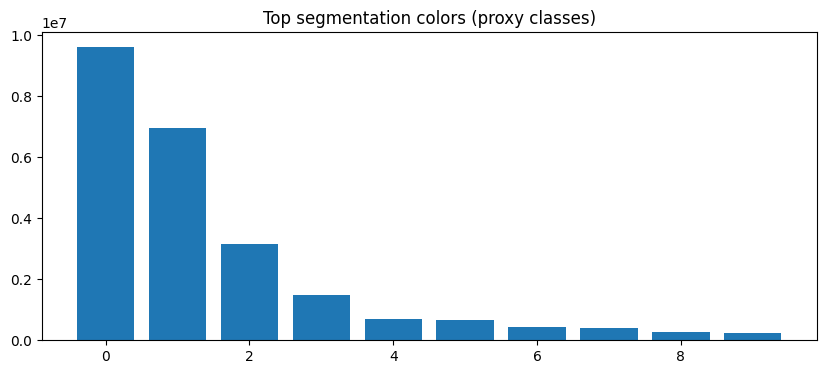

In [14]:
base_dir = "./"
folders = [f"{i:02d}" for i in range(21)]

colors = analyze_segmentation_dataset(base_dir, folders)

In [15]:
from PIL import Image
import numpy as np

# ścieżka do obrazka
path = "00/segmentation_raw/00070796.png"

# wczytanie obrazu
img = Image.open(path)

# konwersja do macierzy
arr = np.array(img)

print(arr)
print("shape:", arr.shape)
print("dtype:", arr.dtype)

[[[  3   0   0 255]
  [  3   0   0 255]
  [  3   0   0 255]
  ...
  [ 11   0   0 255]
  [ 11   0   0 255]
  [ 11   0   0 255]]

 [[  3   0   0 255]
  [  3   0   0 255]
  [  3   0   0 255]
  ...
  [ 11   0   0 255]
  [ 11   0   0 255]
  [ 11   0   0 255]]

 [[  3   0   0 255]
  [  3   0   0 255]
  [  3   0   0 255]
  ...
  [ 11   0   0 255]
  [ 11   0   0 255]
  [ 11   0   0 255]]

 ...

 [[  1   0   0 255]
  [  1   0   0 255]
  [  1   0   0 255]
  ...
  [  1   0   0 255]
  [  1   0   0 255]
  [  1   0   0 255]]

 [[  1   0   0 255]
  [  1   0   0 255]
  [  1   0   0 255]
  ...
  [  1   0   0 255]
  [  1   0   0 255]
  [  1   0   0 255]]

 [[  1   0   0 255]
  [  1   0   0 255]
  [  1   0   0 255]
  ...
  [  1   0   0 255]
  [  1   0   0 255]
  [  1   0   0 255]]]
shape: (480, 640, 4)
dtype: uint8


**Trening modelu** został przeniesiony do notebooka [`train1.ipynb`](train1.ipynb) (mapa klas, `CARLADataset`, `SegModel`, PyTorch Lightning).